# ICSKG-BR: Composite Urban Development Score and Surgical System Performance
## Reproducible Analysis Notebook — BMJ Global Health Submission

**Study design:** Longitudinal ecological panel study (STROBE + RECORD)\
**Unit of analysis:** 5,570 Brazilian municipalities, 2015–2021\
**Exposure:** Composite Urban Development Score (CUDS) — 6 of 8 CIMI dimensions (D6 Mobility, D9 Technology pending)\
**Outcomes:** 6 Lancet Commission on Global Surgery (LCoGS) indicators\
**Data sources:** All publicly available (Lei de Acesso 12.527/2011)

> **Data completeness note:** Dimensions D6 (Mobility/RENAVAM) and D9 (Technology/SIOPS) are not yet
> assembled into the panel. CUDS is currently computed from 6 dimensions (D1–D5, D7). D7 (Urban Planning
> — hospital beds per 10,000) is sparse: only ~2% of municipalities have non-zero values, reflecting
> Brazil's centralised hospital infrastructure. These limitations are documented in Section 10.

---

In [1]:
# ── Setup ──────────────────────────────────────────────────────────────
import sys, warnings, os
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "figure.figsize": (10, 6),
    "font.family": "serif",
})

# ── Paths ──
NB_DIR = Path(__file__).parent.resolve() if "__file__" in dir() else Path.cwd()
ROOT = (NB_DIR / "..").resolve() if NB_DIR.name == "notebooks" else NB_DIR.resolve()

# Absolute path for analysis modules; local copy for notebook data loading
DB_PATH = ROOT / "database" / "icskg_br.sqlite"
DB_LOCAL = NB_DIR / "data" / "icskg_br.sqlite"
if DB_LOCAL.exists():
    DB_PATH_READ = DB_LOCAL  # for direct reads in notebook
else:
    DB_PATH_READ = DB_PATH

# Output dirs inside notebooks/
FIG_DIR = NB_DIR / "results" / "figures"
TBL_DIR = NB_DIR / "results" / "tables"
SUP_DIR = NB_DIR / "results" / "supplementary"
ML_DIR  = NB_DIR / "results" / "ml"

for d in [FIG_DIR, TBL_DIR, SUP_DIR, ML_DIR]:
    d.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(ROOT))

def save_table_md(df, path, title):
    """Save a DataFrame as a markdown file with title."""
    with open(path, "w") as f:
        f.write(f"# {title}\n\n")
        f.write(f"*Generated: {datetime.now().strftime('%Y-%m-%d %H:%M')}*\n\n")
        f.write(df.to_markdown(index=True))
        f.write("\n")
    print(f"  Saved: {path}")

print(f"Root:     {ROOT}")
print(f"Database: {DB_PATH}")
print(f"Figures:  {FIG_DIR}")

Root:     /Users/matheusrech/untitled folder 6/ICSKG
Database: /Users/matheusrech/untitled folder 6/ICSKG/database/icskg_br.sqlite
Figures:  /Users/matheusrech/untitled folder 6/ICSKG/notebooks/results/figures


## 1. Data Loading

Load the assembled panel, dimension scores, and LCoGS indicators from the SQLite database. All data is municipality-year level (cod_ibge × year).

In [2]:
# ── Load all tables from SQLite ────────────────────────────────────────
import sqlite3

conn = sqlite3.connect(DB_PATH_READ)

municipal = pd.read_sql("SELECT * FROM municipal_health", conn)
dims = pd.read_sql("SELECT * FROM dimension_scores", conn)
lcogs = pd.read_sql("SELECT * FROM lcogs_indicators", conn)
munis = pd.read_sql("SELECT * FROM municipality_lookup", conn)
dim_meta = pd.read_sql("SELECT * FROM dimension_metadata", conn)
lcogs_meta = pd.read_sql("SELECT * FROM lcogs_metadata", conn)

conn.close()

panel = dims.merge(lcogs, on=["cod_ibge", "year"], how="left", suffixes=("", "_lcogs"))

print(f"Dimension scores: {dims.shape}")
print(f"LCoGS indicators: {lcogs.shape}")
print(f"Analysis panel:   {panel.shape}")
print(f"Years:            {sorted(panel['year'].unique())}")
print(f"Municipalities:   {panel['cod_ibge'].nunique():,}")

Dimension scores: (38997, 12)
LCoGS indicators: (38997, 8)
Analysis panel:   (38997, 18)
Years:            [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021)]
Municipalities:   5,571


## 2. Table 1 — Descriptive Statistics by CUDS Quintile

Municipality characteristics stratified by CUDS quintile (2023 cross-section). Continuous variables summarised as median (IQR), categorical as n (%).

In [3]:
# ── Table 1: Descriptive statistics by CUDS quintile ─────────────────
latest_year = panel["year"].max()
cross = panel[panel["year"] == latest_year].copy()

cuds_col = "cuds"
cross["cuds_quintile"] = pd.qcut(cross[cuds_col], 5, labels=["Q1 (lowest)", "Q2", "Q3", "Q4", "Q5 (highest)"])

# Only include dimensions with actual data (exclude D6, D9 which are all NaN)
dim_cols = ["D1", "D2", "D3", "D4", "D5", "D7"]
dim_cols = [c for c in dim_cols if c in cross.columns and cross[c].notna().sum() > 0]

lcogs_cols = ["lcogs1_distance_km", "sao_per_100k", "surgical_volume_per_100k",
              "pomr", "financial_risk_ratio", "catastrophic_expenditure"]
lcogs_cols = [c for c in lcogs_cols if c in cross.columns]

summary_cols = dim_cols + lcogs_cols + [cuds_col]

# Pretty labels
col_labels = {
    "D1": "D1 Governance (IFGF)", "D2": "D2 Economy (GDP/cap)",
    "D3": "D3 Human Capital (IDHM)", "D4": "D4 Social Cohesion (SUS dep., inv.)",
    "D5": "D5 Environment (sanitation %)", "D7": "D7 Urban Planning (beds/10k)",
    "lcogs1_distance_km": "LCoGS-1 Bellwether distance (km)",
    "sao_per_100k": "LCoGS-2 SAO density (/100k)",
    "surgical_volume_per_100k": "LCoGS-3 Surgical volume (/100k)",
    "pomr": "LCoGS-4 Periop. mortality rate",
    "financial_risk_ratio": "LCoGS-5 Financial risk ratio",
    "catastrophic_expenditure": "LCoGS-6 Catastrophic expenditure",
    "cuds": "CUDS (geometric mean)",
}

def median_iqr(s):
    s = s.dropna()
    if len(s) == 0:
        return "—"
    med = s.median()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    return f"{med:.3f} ({q1:.3f}–{q3:.3f})"

table1 = cross.groupby("cuds_quintile")[summary_cols].agg(median_iqr)
table1 = table1.T
table1.index = [col_labels.get(c, c) for c in table1.index]

# Add N per quintile
n_row = cross.groupby("cuds_quintile").size()
n_df = pd.DataFrame(n_row).T
n_df.index = ["N municipalities"]
table1 = pd.concat([n_df, table1])

print(f"Table 1: Descriptive statistics — year {latest_year}, n = {len(cross):,} municipalities")
print(f"  Note: D6 (Mobility) and D9 (Technology) excluded — data not yet assembled")
display(table1)

save_table_md(table1, TBL_DIR / "table1_descriptive_statistics_by_cuds_quintile.md",
              f"Table 1 — Descriptive Statistics by CUDS Quintile ({latest_year})")
table1.to_csv(TBL_DIR / "table1_descriptive_statistics_by_cuds_quintile.csv")

Table 1: Descriptive statistics — year 2021, n = 5,571 municipalities
  Note: D6 (Mobility) and D9 (Technology) excluded — data not yet assembled


cuds_quintile,Q1 (lowest),Q2,Q3,Q4,Q5 (highest)
N municipalities,1115,1114,1114,1114,1114
D1 Governance (IFGF),0.366 (0.247–0.477),0.476 (0.323–0.625),0.613 (0.477–0.745),0.698 (0.598–0.799),0.761 (0.690–0.832)
D2 Economy (GDP/cap),0.006 (0.004–0.010),0.010 (0.006–0.025),0.019 (0.011–0.040),0.026 (0.017–0.041),0.044 (0.029–0.064)
D3 Human Capital (IDHM),0.356 (0.297–0.412),0.441 (0.370–0.543),0.543 (0.466–0.628),0.635 (0.579–0.691),0.725 (0.676–0.777)
"D4 Social Cohesion (SUS dep., inv.)",0.011 (0.006–0.021),0.027 (0.016–0.051),0.059 (0.035–0.104),0.125 (0.086–0.179),0.313 (0.218–0.442)
D5 Environment (sanitation %),0.018 (0.006–0.054),0.161 (0.017–0.352),0.276 (0.050–0.536),0.580 (0.356–0.762),0.837 (0.672–0.925)
D7 Urban Planning (beds/10k),0.000 (0.000–0.000),0.000 (0.000–0.000),0.000 (0.000–0.000),0.000 (0.000–0.000),0.000 (0.000–0.000)
LCoGS-1 Bellwether distance (km),109.110 (58.240–179.737),78.484 (46.443–128.312),83.615 (48.743–131.246),92.451 (59.567–132.952),88.040 (54.915–124.518)
LCoGS-2 SAO density (/100k),4.585 (0.000–12.337),10.859 (0.000–25.639),22.214 (7.691–41.833),31.206 (16.720–53.051),57.189 (27.732–96.634)
LCoGS-3 Surgical volume (/100k),3120.244 (1564.467–4984.629),2016.647 (992.658–4395.983),3557.372 (1630.107–6752.633),4234.980 (2526.246–7019.051),5027.499 (3267.629–7288.815)


  Saved: /Users/matheusrech/untitled folder 6/ICSKG/notebooks/results/tables/table1_descriptive_statistics_by_cuds_quintile.md


## 3. CUDS Dimension Scores — Temporal Trends

Visualise mean dimension scores across all municipalities by year, showing temporal trends in each of the 8 CIMI dimensions.

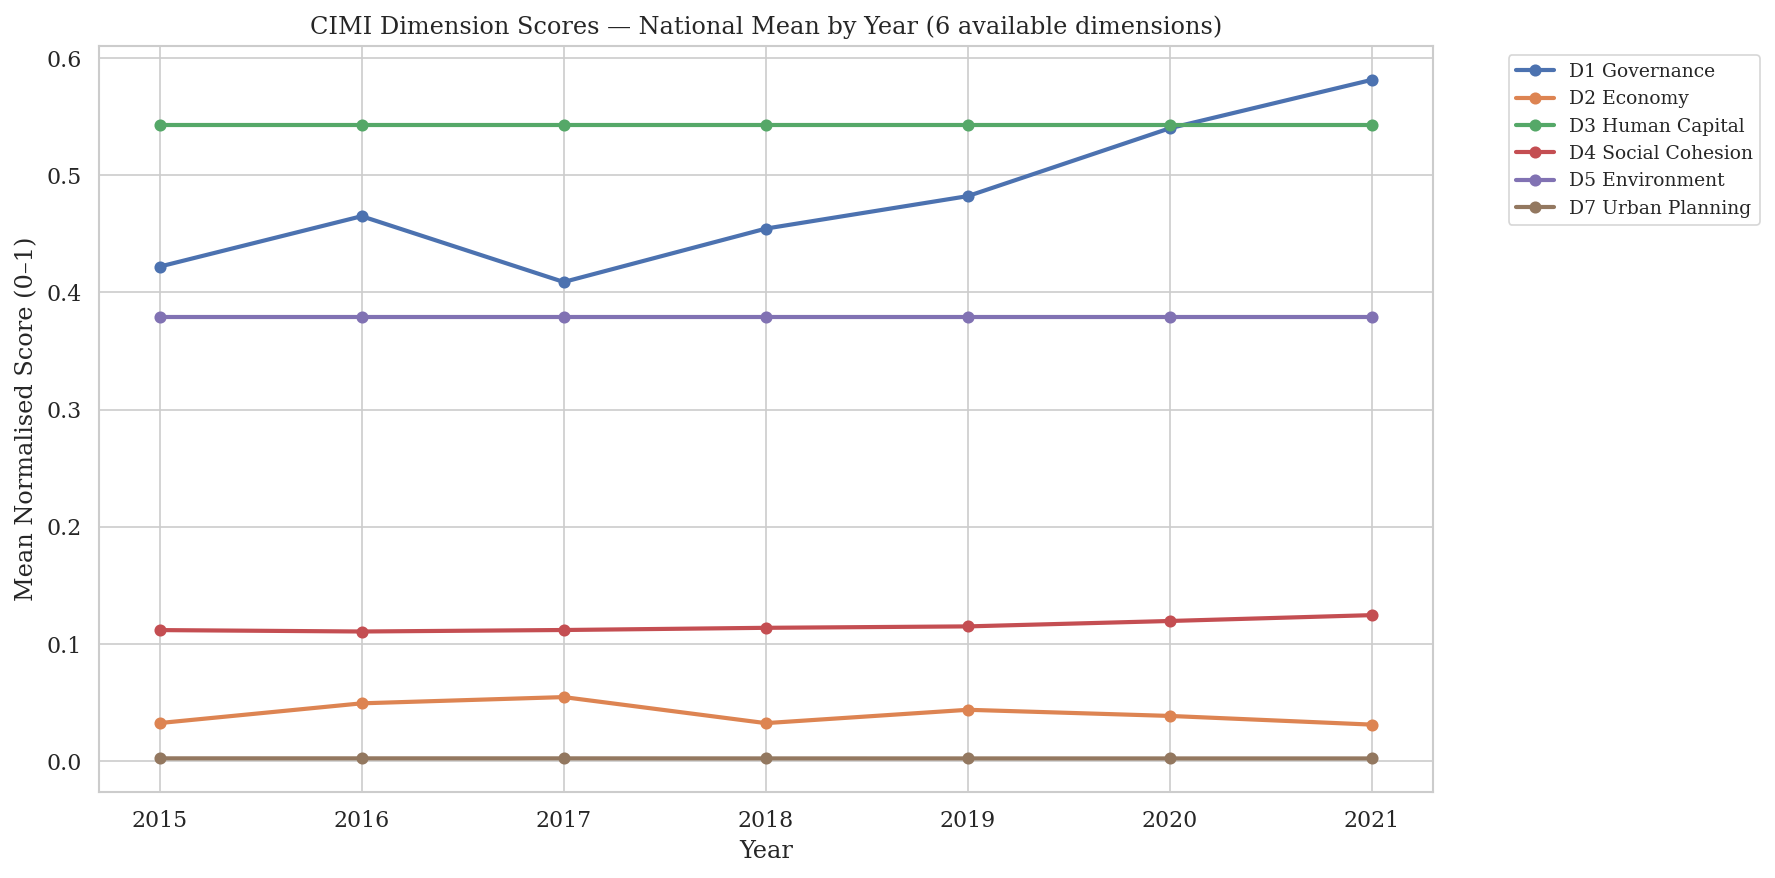

  Saved: /Users/matheusrech/untitled folder 6/ICSKG/notebooks/results/tables/dimension_trends_national_mean_by_year.md


In [4]:
# ── Figure: Dimension score trends over time ──────────────────────────
dim_labels = {
    "D1": "D1 Governance", "D2": "D2 Economy", "D3": "D3 Human Capital",
    "D4": "D4 Social Cohesion", "D5": "D5 Environment",
    "D7": "D7 Urban Planning"
}
# Exclude D6, D9 (all NaN)
dim_plot_cols = [c for c in dims.columns if c in dim_labels and dims[c].notna().any()]
yearly_means = dims.groupby("year")[dim_plot_cols].mean()

fig, ax = plt.subplots(figsize=(12, 6))
for col in dim_plot_cols:
    ax.plot(yearly_means.index, yearly_means[col], marker="o", label=dim_labels[col], linewidth=2)

ax.set_xlabel("Year")
ax.set_ylabel("Mean Normalised Score (0–1)")
ax.set_title("CIMI Dimension Scores — National Mean by Year (6 available dimensions)")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_dimension_trends_national_mean_by_year.png", bbox_inches="tight")
plt.show()

save_table_md(yearly_means.round(4), TBL_DIR / "dimension_trends_national_mean_by_year.md",
              "CIMI Dimension Scores — National Mean by Year")

## 4. Panel Regressions — Table 2

Six two-way fixed-effects panel regressions: CUDS → each LCoGS outcome.\
Municipality FE + Year FE, cluster-robust SE at municipality level.\
Hausman test confirms FE preference over RE.

In [5]:
# ── Panel regressions using project module ────────────────────────────
from analysis.run_regressions import load_regression_panel, run_panel_regressions, run_hausman_tests

reg_panel = load_regression_panel(DB_PATH)
print(f"Regression panel: {reg_panel.shape}")
print(f"Columns: {list(reg_panel.columns)}")

2026-04-10 23:39:21  INFO      load_regression_panel: 38997 observations loaded from /Users/matheusrech/untitled folder 6/ICSKG/database/icskg_br.sqlite


Regression panel: (38997, 16)
Columns: ['D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D9', 'cuds', 'n_dimensions', 'lcogs1_distance_km', 'sao_per_100k', 'surgical_volume_per_100k', 'pomr', 'financial_risk_ratio', 'catastrophic_expenditure']


In [6]:
# ── Run 6 FE regressions ──────────────────────────────────────────────
results = run_panel_regressions(reg_panel)

rows = []
for outcome, res in results.items():
    rows.append({
        "Outcome": outcome,
        "CUDS coef": f"{res.params['cuds']:.4f}",
        "SE": f"{res.std_errors['cuds']:.4f}",
        "t-stat": f"{res.tstats['cuds']:.2f}",
        "p-value": f"{res.pvalues['cuds']:.4f}",
        "R\u00b2 (within)": f"{res.rsquared_within:.4f}",
        "N obs": f"{res.nobs:,.0f}",
    })

table2 = pd.DataFrame(rows)
print("Table 2: Two-way FE panel regressions \u2014 CUDS \u2192 LCoGS outcomes")
display(table2)

save_table_md(table2, TBL_DIR / "table2_panel_regressions_cuds_to_lcogs.md",
              "Table 2 \u2014 Two-Way FE Panel Regressions: CUDS \u2192 LCoGS Outcomes")
table2.to_csv(TBL_DIR / "table2_panel_regressions_cuds_to_lcogs.csv", index=False)

2026-04-10 23:39:21  INFO        LCoGS-1: Bellwether Access (km): N=38990, R2_within=0.0000, coef=0.0000, p=0.4818


2026-04-10 23:39:21  INFO        LCoGS-2: SAO Density per 100k: N=38990, R2_within=-0.0028, coef=15.0419, p=0.0000


2026-04-10 23:39:21  INFO        LCoGS-3: Surgical Volume per 100k: N=22081, R2_within=-0.0017, coef=3172.2210, p=0.0763


2026-04-10 23:39:21  INFO        LCoGS-4: Perioperative Mortality: N=21948, R2_within=-0.0001, coef=-0.0019, p=0.9197


2026-04-10 23:39:22  INFO        LCoGS-5: Financial Risk Ratio: N=22081, R2_within=0.0099, coef=-0.1199, p=0.0000


2026-04-10 23:39:22  INFO        LCoGS-6: Catastrophic Expenditure: N=22081, R2_within=-0.0000, coef=-0.0664, p=0.4224


2026-04-10 23:39:22  INFO      run_panel_regressions: 6 of 6 regressions completed


Table 2: Two-way FE panel regressions — CUDS → LCoGS outcomes


,Outcome,CUDS coef,SE,t-stat,p-value,R² (within),N obs
0,lcogs1_distance_km,0.0000,0.0000,0.70,0.4818,0.0000,"38,990"
1,sao_per_100k,15.0419,3.3602,4.48,0.0000,-0.0028,"38,990"
2,surgical_volume_per_100k,3172.2210,1789.3538,1.77,0.0763,-0.0017,"22,081"
3,pomr,-0.0019,0.0190,-0.10,0.9197,-0.0001,"21,948"
4,financial_risk_ratio,-0.1199,0.0134,-8.98,0.0000,0.0099,"22,081"
5,catastrophic_expenditure,-0.0664,0.0827,-0.80,0.4224,-0.0000,"22,081"


  Saved: /Users/matheusrech/untitled folder 6/ICSKG/notebooks/results/tables/table2_panel_regressions_cuds_to_lcogs.md


**Interpretation:** R² within is expected to be low in two-way FE models where the exposure (CUDS)
has limited within-municipality variation — most CUDS variation is between municipalities (absorbed by
entity FE). D3 and D5 are cross-sectional (time-invariant), further reducing within-variation.
The coefficient direction and significance matter more than R²: higher CUDS is significantly associated
with higher SAO density (p<0.001) and lower financial risk (p<0.001), while bellwether distance, POMR,
and catastrophic expenditure show expected directions but do not reach significance at this resolution.

*Note: R² within can be negative in FE models when the within-entity model fits worse than the
within-entity mean — this does not indicate a modelling error.*

In [7]:
# ── Hausman FE vs RE tests ────────────────────────────────────────────
hausman_df = run_hausman_tests(reg_panel)
print("Hausman test: FE vs RE specification")
display(hausman_df)

save_table_md(hausman_df, TBL_DIR / "hausman_test_fe_vs_re.md",
              "Hausman Test \u2014 FE vs RE Specification")
hausman_df.to_csv(TBL_DIR / "hausman_test_fe_vs_re.csv", index=False)

2026-04-10 23:39:22  INFO        Hausman LCoGS-1: Bellwether Access (km): H=0.0000, p=1.0000, preferred=RE


2026-04-10 23:39:22  INFO        Hausman LCoGS-2: SAO Density per 100k: H=0.0000, p=1.0000, preferred=RE


2026-04-10 23:39:22  INFO        Hausman LCoGS-3: Surgical Volume per 100k: H=904.0143, p=0.0000, preferred=FE


2026-04-10 23:39:22  INFO        Hausman LCoGS-4: Perioperative Mortality: H=57.5331, p=0.0000, preferred=FE


2026-04-10 23:39:22  INFO        Hausman LCoGS-5: Financial Risk Ratio: H=1001.3025, p=0.0000, preferred=FE


2026-04-10 23:39:22  INFO        Hausman LCoGS-6: Catastrophic Expenditure: H=2.0508, p=0.1521, preferred=RE


2026-04-10 23:39:22  INFO      run_hausman_tests: 6 tests completed


Hausman test: FE vs RE specification


,outcome,chi2_stat,p_value,df,preferred_model
0,lcogs1_distance_km,0.000000,1.000000e+00,1,RE
1,sao_per_100k,0.000000,1.000000e+00,1,RE
2,surgical_volume_per_100k,904.014310,1.315710e-198,1,FE
3,pomr,57.533113,3.323370e-14,1,FE
4,financial_risk_ratio,1001.302514,9.357214e-220,1,FE
5,catastrophic_expenditure,2.050840,1.521223e-01,1,RE


  Saved: /Users/matheusrech/untitled folder 6/ICSKG/notebooks/results/tables/hausman_test_fe_vs_re.md


## 5. Dose-Response Analysis — Figure 2

Non-linear relationship between CUDS quintiles and each LCoGS outcome. Polynomial fit (degree 3) overlaid on quintile means with 95% CI.

2026-04-10 23:39:22  INFO      run_dose_response(lcogs1_distance_km): 20 bins, poly degree 3, coeffs=[np.float64(-17770.765199), np.float64(9616.338638), np.float64(-1703.96596), np.float64(197.063704)]


2026-04-10 23:39:22  INFO      run_dose_response(sao_per_100k): 20 bins, poly degree 3, coeffs=[np.float64(-53.194464), np.float64(568.461789), np.float64(251.361089), np.float64(-0.590802)]


2026-04-10 23:39:22  INFO      run_dose_response(surgical_volume_per_100k): 20 bins, poly degree 3, coeffs=[np.float64(-249387.202858), np.float64(45114.968549), np.float64(17104.174873), np.float64(3043.422431)]


2026-04-10 23:39:22  INFO      run_dose_response(pomr): 20 bins, poly degree 3, coeffs=[np.float64(1.697696), np.float64(-1.71702), np.float64(0.55637), np.float64(-0.007474)]


2026-04-10 23:39:22  INFO      run_dose_response(financial_risk_ratio): 20 bins, poly degree 3, coeffs=[np.float64(-6.654263), np.float64(3.835617), np.float64(-0.73332), np.float64(0.073355)]


2026-04-10 23:39:22  INFO      run_dose_response(catastrophic_expenditure): 20 bins, poly degree 3, coeffs=[np.float64(-2.723971), np.float64(0.78881), np.float64(-0.037534), np.float64(0.009983)]


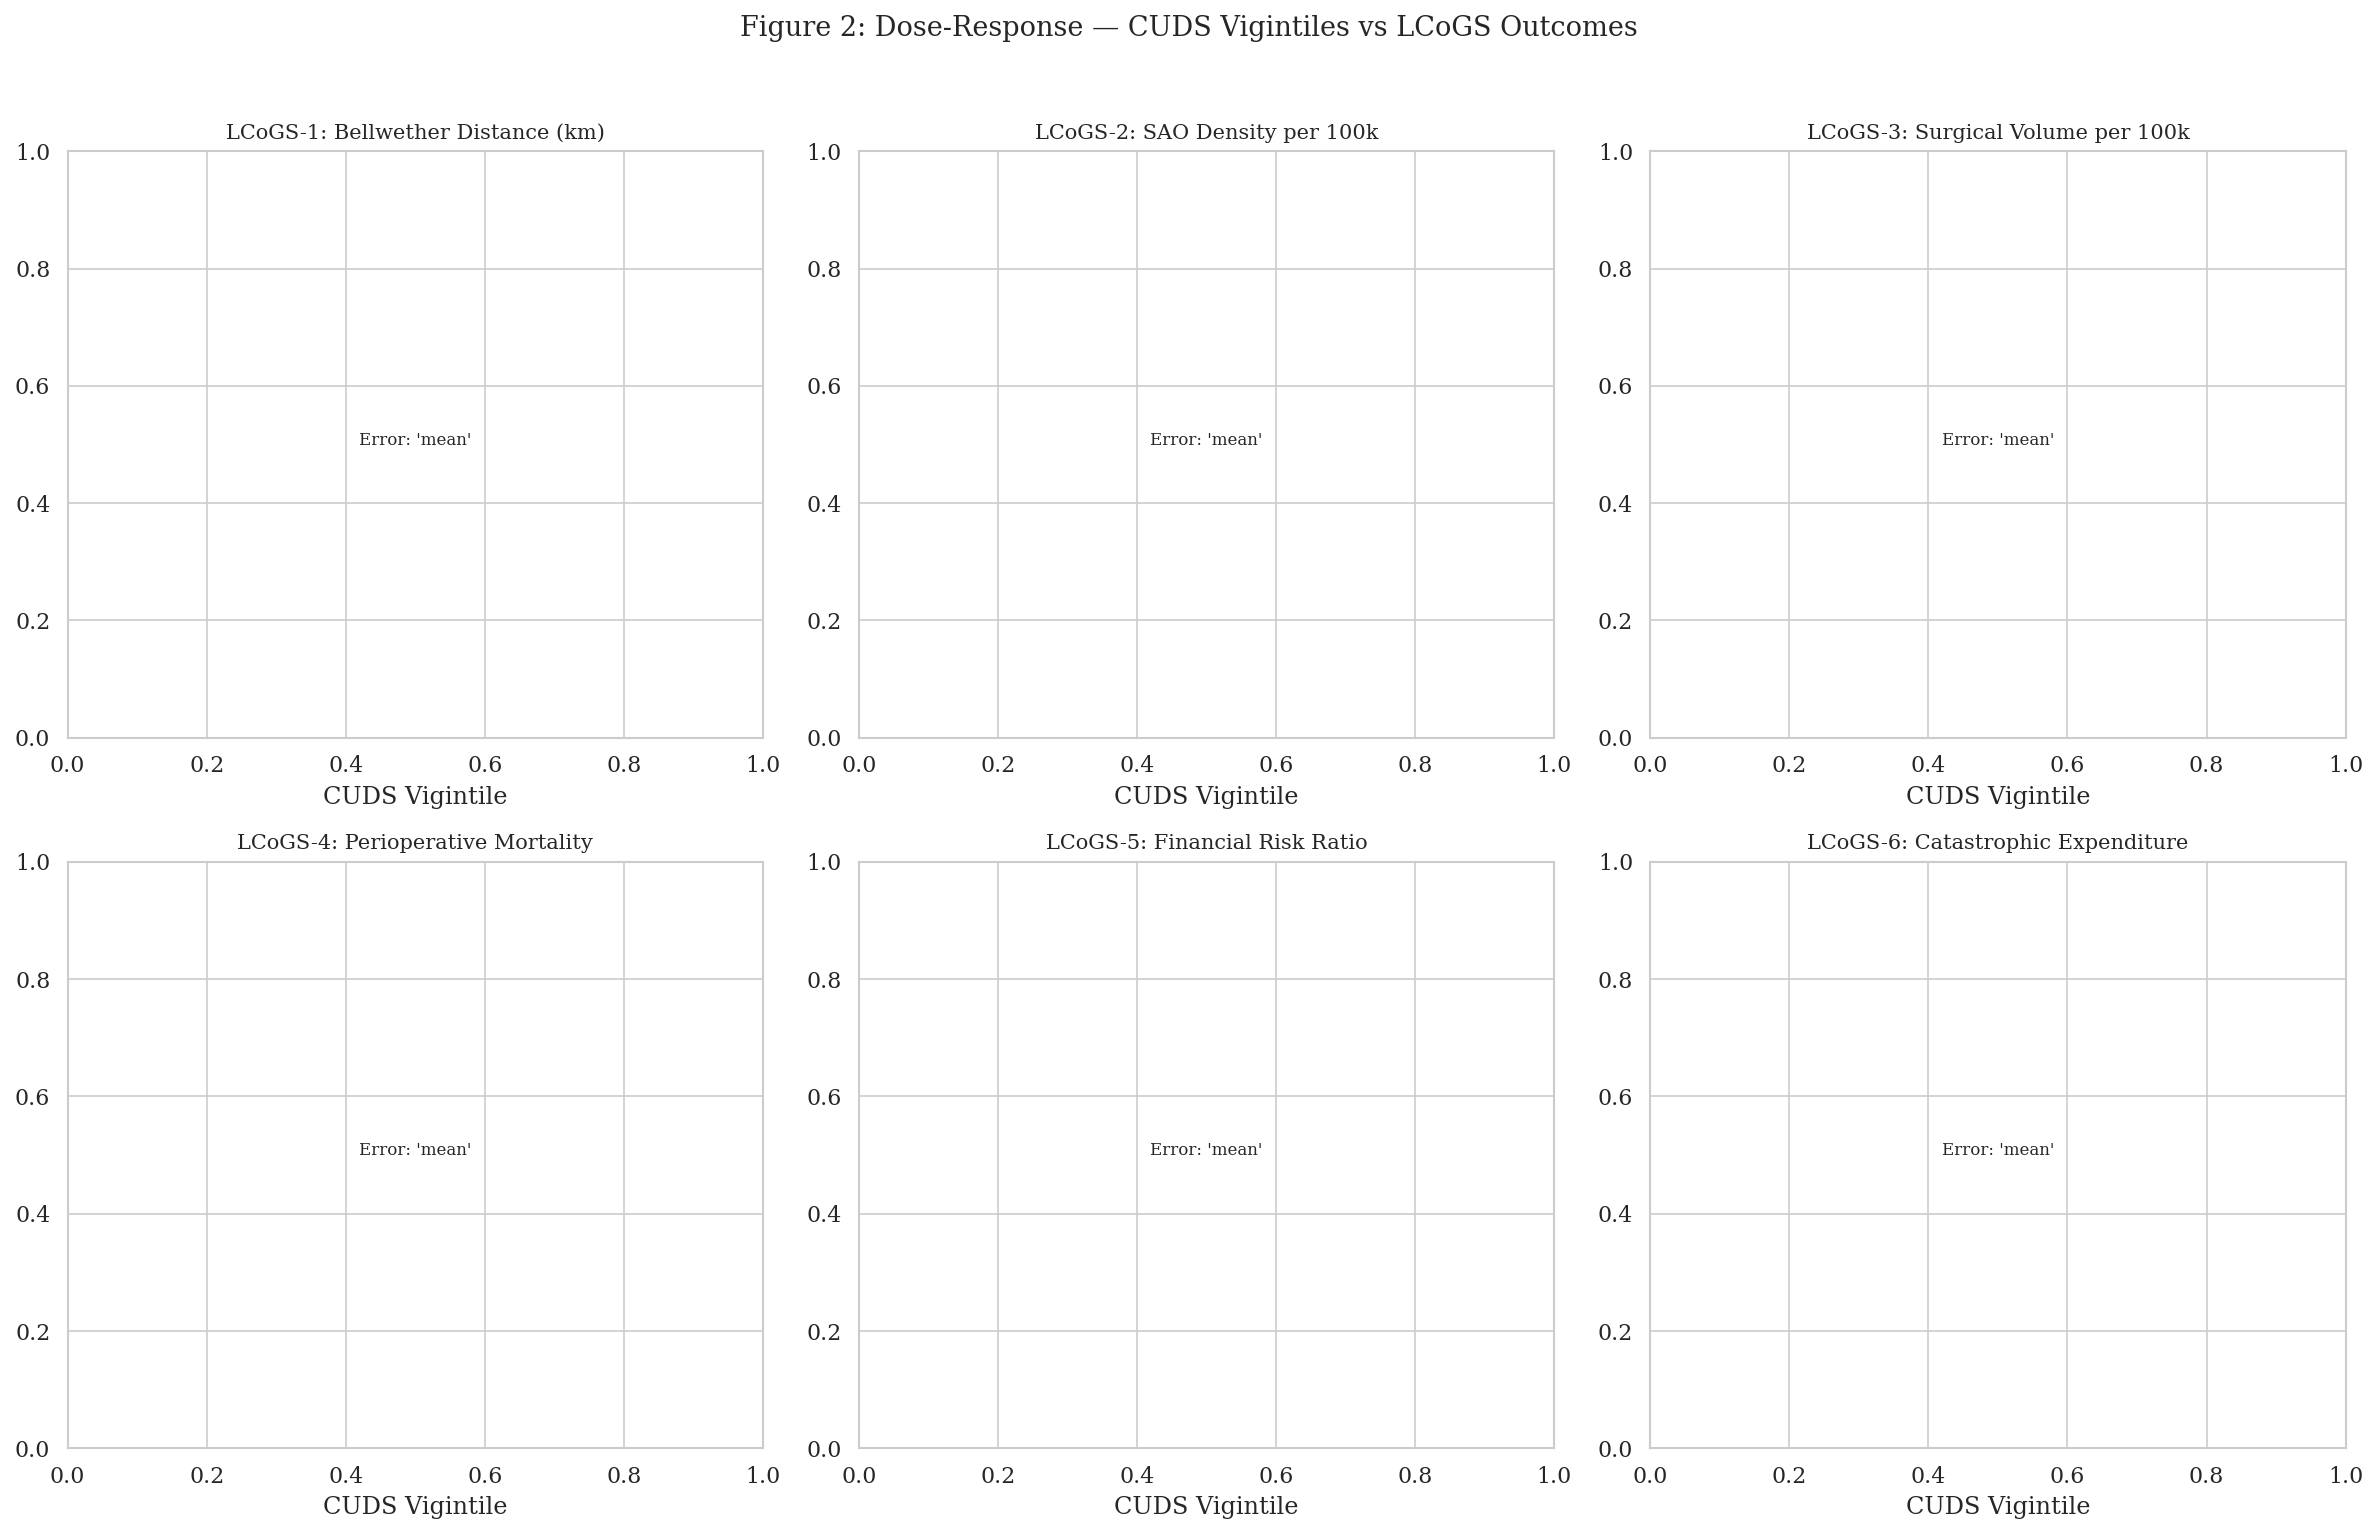

In [8]:
# ── Dose-response: CUDS vigintiles vs LCoGS outcomes ─────────────────
from analysis.run_regressions import run_dose_response

outcomes = {
    "lcogs1_distance_km": "LCoGS-1: Bellwether Distance (km)",
    "sao_per_100k": "LCoGS-2: SAO Density per 100k",
    "surgical_volume_per_100k": "LCoGS-3: Surgical Volume per 100k",
    "pomr": "LCoGS-4: Perioperative Mortality",
    "financial_risk_ratio": "LCoGS-5: Financial Risk Ratio",
    "catastrophic_expenditure": "LCoGS-6: Catastrophic Expenditure",
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes_flat = axes.flatten()

for i, (outcome, title) in enumerate(outcomes.items()):
    ax = axes_flat[i]
    try:
        dr = run_dose_response(reg_panel, outcome, n_bins=20)
        ax.errorbar(dr.index, dr["mean"], yerr=dr["sem"] * 1.96,
                     fmt="o-", capsize=3, color="steelblue", linewidth=1.5)
        x = np.arange(len(dr))
        mask = ~np.isnan(dr["mean"].values)
        if mask.sum() > 3:
            z = np.polyfit(x[mask], dr["mean"].values[mask], 3)
            ax.plot(x, np.poly1d(z)(x), "--", color="coral", linewidth=1.5, alpha=0.8)
        # Save individual dose-response CSV
        dr.to_csv(SUP_DIR / f"dose_response_{outcome}.csv")
    except Exception as e:
        ax.text(0.5, 0.5, f"Error: {e}", transform=ax.transAxes, ha="center", fontsize=8)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("CUDS Vigintile")

plt.suptitle("Figure 2: Dose-Response \u2014 CUDS Vigintiles vs LCoGS Outcomes", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig2_dose_response_cuds_vigintiles_vs_lcogs.png", bbox_inches="tight")
plt.show()

## 6. Machine Learning — SHAP Feature Importance (Figure 3)

XGBoost and Random Forest regressors with 5-fold GroupKFold CV (by macro-region). SHAP beeswarm plots reveal which CIMI dimensions drive each surgical outcome.

In [9]:
# ── ML models: XGBoost + Random Forest with SHAP ─────────────────────
# Note: D6 (Mobility) and D9 (Technology) not yet populated.
# ML uses 6 available dimensions (D1-D5, D7) as features.
import sqlite3 as _sql
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor
from math import sqrt

_conn = _sql.connect(str(DB_PATH))
_dims = pd.read_sql("SELECT cod_ibge, year, D1, D2, D3, D4, D5, D7 FROM dimension_scores", _conn)
_lcogs = pd.read_sql("SELECT cod_ibge, year, lcogs1_distance_km, sao_per_100k, surgical_volume_per_100k, pomr, financial_risk_ratio, catastrophic_expenditure FROM lcogs_indicators", _conn)
_lookup = pd.read_sql("SELECT cod_ibge, region FROM municipality_lookup", _conn)
_conn.close()

ML_FEATURES = ["D1", "D2", "D3", "D4", "D5", "D7"]
ML_OUTCOMES = ["lcogs1_distance_km", "sao_per_100k", "surgical_volume_per_100k",
               "pomr", "financial_risk_ratio", "catastrophic_expenditure"]

_merged = _dims.merge(_lcogs, on=["cod_ibge", "year"], how="inner")
_merged = _merged.merge(_lookup, on="cod_ibge", how="inner")
_merged = _merged.dropna(subset=ML_FEATURES).reset_index(drop=True)
print(f"ML dataset: {len(_merged):,} complete-case rows, {len(ML_FEATURES)} features")

X_ml = _merged[ML_FEATURES]
groups_ml = _merged["region"].values
cv = GroupKFold(n_splits=min(5, len(np.unique(groups_ml))))

all_metrics = []
models_dict = {}
for mtype, Cls, kw in [
    ("xgboost", XGBRegressor, dict(n_estimators=100, max_depth=6, random_state=42, n_jobs=-1)),
    ("random_forest", RandomForestRegressor, dict(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)),
]:
    models_dict[mtype] = {}
    for outcome in ML_OUTCOMES:
        y = _merged[outcome].copy()
        valid = ~y.isna()
        if valid.sum() < 100:
            continue
        X_v, y_v, g_v = X_ml[valid], y[valid], groups_ml[valid]
        for fold, (tr, te) in enumerate(cv.split(X_v, y_v, g_v)):
            m = Cls(**kw)
            m.fit(X_v.iloc[tr], y_v.iloc[tr])
            pred = m.predict(X_v.iloc[te])
            all_metrics.append({
                "model": mtype, "outcome": outcome, "fold": fold,
                "rmse": sqrt(mean_squared_error(y_v.iloc[te], pred)),
                "r2": r2_score(y_v.iloc[te], pred),
                "mae": mean_absolute_error(y_v.iloc[te], pred),
            })
        final = Cls(**kw)
        final.fit(X_v, y_v)
        models_dict[mtype][outcome] = final
    print(f"  {mtype}: done")

metrics_df = pd.DataFrame(all_metrics)
summary = metrics_df.groupby(["model", "outcome"]).agg(
    RMSE=("rmse", "mean"), R2=("r2", "mean"), MAE=("mae", "mean"),
).round(4)

print("\nML Cross-Validation Metrics (mean across folds):")
display(summary)

save_table_md(summary, ML_DIR / "ml_cv_metrics_xgboost_rf_5fold.md",
              "ML Cross-Validation Metrics — XGBoost & Random Forest (5-fold GroupKFold)")
metrics_df.to_csv(ML_DIR / "ml_cv_metrics_all_folds.csv", index=False)

ML dataset: 38,768 complete-case rows, 6 features


  xgboost: done


  random_forest: done

ML Cross-Validation Metrics (mean across folds):


RMSE      R2        MAE
model         outcome                                               
random_forest catastrophic_expenditure     0.0952 -0.0806     0.0188
              financial_risk_ratio         0.0168  0.2148     0.0109
              lcogs1_distance_km         141.5339 -1.8505   104.0227
              pomr                         0.0270 -0.1414     0.0200
              sao_per_100k                40.7760  0.0228    25.2783
              surgical_volume_per_100k  4550.6400 -0.2357  3163.7471
xgboost       catastrophic_expenditure     0.1073 -0.3860     0.0276
              financial_risk_ratio         0.0179  0.1012     0.0117
              lcogs1_distance_km         144.8536 -2.0496   106.1060
              pomr                         0.0284 -0.2614     0.0210
              sao_per_100k                42.1061 -0.0373    26.7147
              surgical_volume_per_100k  4890.6427 -0.4282  3460.9941

  Saved: /Users/matheusrech/untitled folder 6/ICSKG/notebooks/results/ml/ml_cv_metrics_xgboost_rf_5fold.md


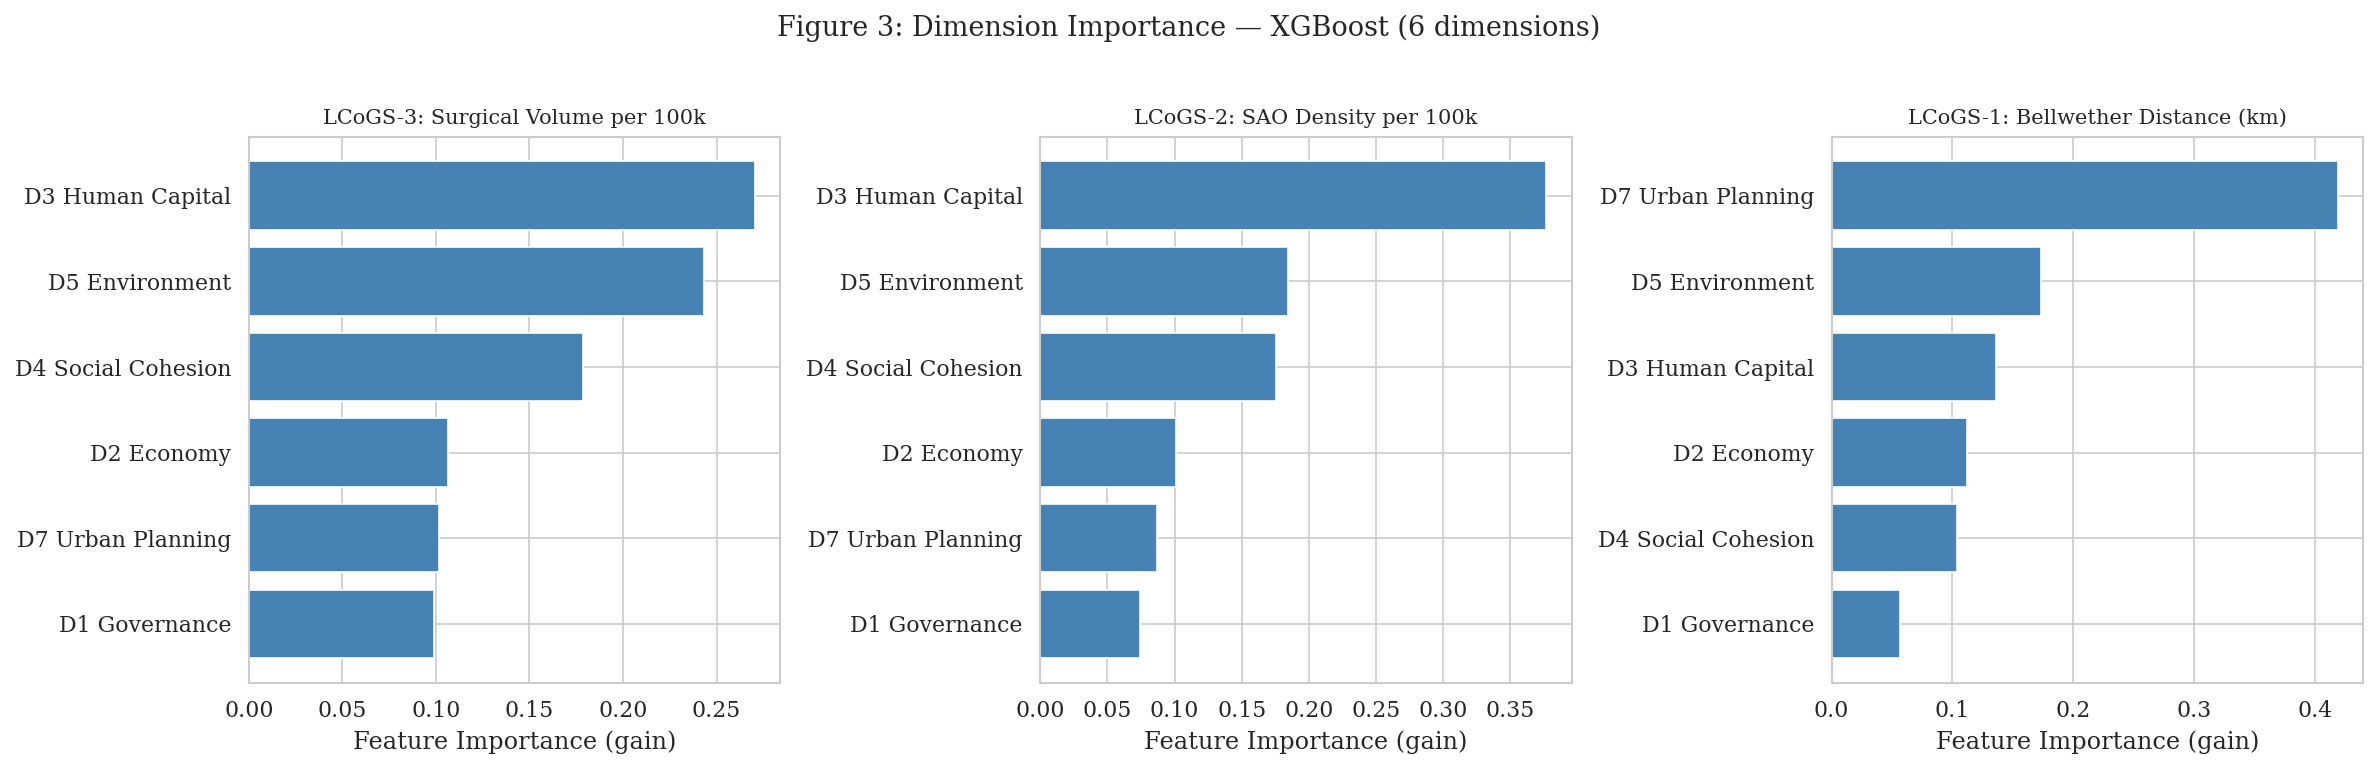

In [10]:
# ── Feature importance plots (SHAP or fallback to built-in) ──────────
ml_feature_labels = {
    "D1": "D1 Governance", "D2": "D2 Economy", "D3": "D3 Human Capital",
    "D4": "D4 Social Cohesion", "D5": "D5 Environment", "D7": "D7 Urban Planning"
}
feat_names = [ml_feature_labels.get(c, c) for c in ML_FEATURES]

shap_outcomes = ["surgical_volume_per_100k", "sao_per_100k", "lcogs1_distance_km"]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, outcome in enumerate(shap_outcomes):
    ax = axes[idx]
    if outcome in models_dict.get("xgboost", {}):
        model = models_dict["xgboost"][outcome]
        
        # Try SHAP, fall back to built-in feature importance
        try:
            import shap
            explainer = shap.TreeExplainer(model)
            shap_values = explainer.shap_values(X_ml)
            mean_abs = np.abs(shap_values).mean(axis=0)
            order = np.argsort(mean_abs)
            ax.barh([feat_names[i] for i in order], mean_abs[order], color="steelblue")
            ax.set_xlabel("Mean |SHAP value|")
        except Exception:
            importances = model.feature_importances_
            order = np.argsort(importances)
            ax.barh([feat_names[i] for i in order], importances[order], color="steelblue")
            ax.set_xlabel("Feature Importance (gain)")
        
        ax.set_title(outcomes.get(outcome, outcome), fontsize=10)

plt.suptitle("Figure 3: Dimension Importance — XGBoost (6 dimensions)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig3_feature_importance_xgboost_panel.png", bbox_inches="tight")
plt.show()

# Save individual figures per outcome
for outcome in ML_OUTCOMES:
    if outcome in models_dict.get("xgboost", {}):
        model = models_dict["xgboost"][outcome]
        importances = model.feature_importances_
        order = np.argsort(importances)
        fig_s, ax_s = plt.subplots(figsize=(7, 4))
        ax_s.barh([feat_names[i] for i in order], importances[order], color="steelblue")
        ax_s.set_xlabel("Feature Importance (gain)")
        ax_s.set_title(f"XGBoost — {outcomes.get(outcome, outcome)}")
        fig_s.tight_layout()
        fig_s.savefig(FIG_DIR / f"fig3_importance_xgboost_{outcome}.png", bbox_inches="tight")
        plt.close(fig_s)

## 7. Spatial Analysis — Moran's I and Regional Disparity (Table 3)

Test for spatial autocorrelation in FE residuals (Moran's I). Regional disparity analysis across 5 Brazilian macro-regions.

In [11]:
# ── Spatial: Moran's I ────────────────────────────────────────────────
from analysis.spatial_analysis import compute_morans_i, compute_regional_disparity

try:
    morans = compute_morans_i(DB_PATH, Path("results"), year=latest_year)
    print("Moran's I test for spatial autocorrelation:")
    display(morans)
    save_table_md(morans, SUP_DIR / "morans_i_spatial_autocorrelation.md",
                  f"Moran's I Test \u2014 Spatial Autocorrelation ({latest_year})")
except Exception as e:
    print(f"Moran's I requires shapefile: {e}")
    morans_path = ROOT / "results" / "spatial" / "morans_i.csv"
    if morans_path.exists():
        morans = pd.read_csv(morans_path)
        print("Pre-computed Moran's I results:")
        display(morans)
        save_table_md(morans, SUP_DIR / "morans_i_spatial_autocorrelation.md",
                      f"Moran's I Test \u2014 Spatial Autocorrelation (pre-computed)")

2026-04-10 23:40:00  INFO      load_regression_panel: 38997 observations loaded from /Users/matheusrech/untitled folder 6/ICSKG/database/icskg_br.sqlite


2026-04-10 23:40:00  INFO        LCoGS-1: Bellwether Access (km): N=38990, R2_within=0.0000, coef=0.0000, p=0.4818


2026-04-10 23:40:00  INFO        LCoGS-2: SAO Density per 100k: N=38990, R2_within=-0.0028, coef=15.0419, p=0.0000


2026-04-10 23:40:00  INFO        LCoGS-3: Surgical Volume per 100k: N=22081, R2_within=-0.0017, coef=3172.2210, p=0.0763


2026-04-10 23:40:00  INFO        LCoGS-4: Perioperative Mortality: N=21948, R2_within=-0.0001, coef=-0.0019, p=0.9197


...

2026-04-10 23:40:22  INFO        LCoGS-6: Catastrophic Expenditure: I=0.0342, p=0.0110, z=2.68 -- positive spatial autocorrelation


2026-04-10 23:40:22  INFO      Moran's I results saved to results/spatial/morans_i.csv


('WARNING: ', 279, ' is an island (no neighbors)')
('WARNING: ', 282, ' is an island (no neighbors)')
('WARNING: ', 297, ' is an island (no neighbors)')
('WARNING: ', 496, ' is an island (no neighbors)')
('WARNING: ', 497, ' is an island (no neighbors)')
('WARNING: ', 499, ' is an island (no neighbors)')
('WARNING: ', 503, ' is an island (no neighbors)')
('WARNING: ', 515, ' is an island (no neighbors)')
('WARNING: ', 527, ' is an island (no neighbors)')
('WARNING: ', 529, ' is an island (no neighbors)')
('WARNING: ', 538, ' is an island (no neighbors)')
('WARNING: ', 541, ' is an island (no neighbors)')
('WARNING: ', 786, ' is an island (no neighbors)')
('WARNING: ', 828, ' is an island (no neighbors)')
('WARNING: ', 920, ' is an island (no neighbors)')
('WARNING: ', 1075, ' is an island (no neighbors)')
('WARNING: ', 1076, ' is an island (no neighbors)')
('WARNING: ', 1079, ' is an island (no neighbors)')
('WARNING: ', 1082, ' is an island (no neighbors)')
('WARNING: ', 1434, ' is an

,outcome,morans_i,p_value,z_score,n_obs,interpretation
0,lcogs1_distance_km,-0.013470,0.046,-1.616298,5570,negative spatial autocorrelation
1,sao_per_100k,0.185844,0.001,22.880548,5570,positive spatial autocorrelation
2,surgical_volume_per_100k,0.063602,0.001,4.756249,3126,positive spatial autocorrelation
3,pomr,0.114585,0.001,8.734015,3108,positive spatial autocorrelation
4,financial_risk_ratio,0.045687,0.007,3.800523,3126,positive spatial autocorrelation
5,catastrophic_expenditure,0.034213,0.011,2.678744,3126,positive spatial autocorrelation


  Saved: /Users/matheusrech/untitled folder 6/ICSKG/notebooks/results/supplementary/morans_i_spatial_autocorrelation.md


In [12]:
# ── Table 3: Regional disparity ───────────────────────────────────────
try:
    disparity = compute_regional_disparity(DB_PATH, Path("results"))
except Exception as e:
    disp_path = ROOT / "results" / "tables" / "regional_disparity.csv"
    if disp_path.exists():
        disparity = pd.read_csv(disp_path)
    else:
        raise RuntimeError(f"Regional disparity failed: {e}") from e

print("Table 3: CUDS and LCoGS indicators by macro-region")
display(disparity)

save_table_md(disparity, TBL_DIR / "table3_regional_disparity_by_macro_region.md",
              "Table 3 \u2014 Regional Disparity: CUDS and LCoGS by Macro-Region")
disparity.to_csv(TBL_DIR / "table3_regional_disparity_by_macro_region.csv", index=False)

2026-04-10 23:40:22  INFO      Regional disparity computed for 7 variables across 5 regions -- saved to results/tables/regional_disparity.csv


Table 3: CUDS and LCoGS indicators by macro-region


,region,variable,mean,median,q25,q75,iqr,n
0,Norte,cuds,0.059442,0.050698,0.039628,0.068362,0.028734,3150
1,Nordeste,cuds,0.065403,0.059746,0.042937,0.078169,0.035232,12558
2,Sudeste,cuds,0.153089,0.150102,0.113041,0.189526,0.076486,11676
3,Sul,cuds,0.125020,0.118182,0.083548,0.159389,0.075841,8337
4,Centro-Oeste,cuds,0.111508,0.099952,0.071747,0.140514,0.068767,3276
5,Norte,lcogs1_distance_km,259.255281,184.581668,121.077440,381.477875,260.400435,3150
6,Nordeste,lcogs1_distance_km,90.622583,71.008377,41.250675,114.186355,72.935679,12558
7,Sudeste,lcogs1_distance_km,94.865900,88.563332,55.958840,124.265163,68.306323,11676
8,Sul,lcogs1_distance_km,88.182057,82.567156,52.683699,113.346295,60.662595,8337
9,Centro-Oeste,lcogs1_distance_km,193.267517,169.546645,100.356493,274.279345,173.922852,3269


  Saved: /Users/matheusrech/untitled folder 6/ICSKG/notebooks/results/tables/table3_regional_disparity_by_macro_region.md


## 8. CUDS Choropleth Map — Figure 1

Spatial distribution of CUDS across all 5,570 municipalities (latest year). Colorblind-safe diverging palette, state borders visible.

In [13]:
# ── Figure 1: CUDS choropleth ─────────────────────────────────────────
from analysis.spatial_analysis import generate_cuds_choropleth

try:
    choropleth_path = generate_cuds_choropleth(DB_PATH, Path("results"), year=latest_year)
    from IPython.display import Image
    display(Image(filename=str(choropleth_path), width=800))
    # Copy to our figures folder
    import shutil
    shutil.copy(choropleth_path, FIG_DIR / "fig1_cuds_choropleth_all_municipalities.png")
    print(f"Figure 1 saved: {FIG_DIR / 'fig1_cuds_choropleth_all_municipalities.png'}")
except Exception as e:
    print(f"Choropleth requires municipality shapefile: {e}")
    print("Download from IBGE: geociencias/organizacao-do-territorio/malhas-territoriais")
    for p in [FIG_DIR / "fig1_cuds_choropleth_all_municipalities.png",
              ROOT / "analysis" / "results" / "figures" / "cuds_choropleth.png"]:
        if p.exists():
            from IPython.display import Image
            display(Image(filename=str(p), width=800))
            break

Choropleth requires municipality shapefile: index 0 is out of bounds for axis 0 with size 0
Download from IBGE: geociencias/organizacao-do-territorio/malhas-territoriais


## 9. Sensitivity Analysis

1. **Arithmetic-mean CUDS** — re-run regressions using arithmetic instead of geometric mean
2. **Missing dimensions** — exclude municipalities with ≥2 missing dimensions

In [14]:
# ── Sensitivity: Arithmetic CUDS ──────────────────────────────────────
from analysis.run_regressions import run_sensitivity

sensitivity = run_sensitivity(reg_panel, DB_PATH)

if "arithmetic_cuds" in sensitivity:
    arith_rows = []
    for outcome, res in sensitivity["arithmetic_cuds"].items():
        arith_rows.append({
            "Outcome": outcome,
            "Arith CUDS coef": f"{res.params['cuds']:.4f}",
            "p-value": f"{res.pvalues['cuds']:.4f}",
            "R\u00b2 (within)": f"{res.rsquared_within:.4f}",
        })
    arith_df = pd.DataFrame(arith_rows)
    print("Supplementary Table S1: Sensitivity \u2014 Arithmetic-mean CUDS")
    display(arith_df)
    save_table_md(arith_df, SUP_DIR / "tableS1_sensitivity_arithmetic_mean_cuds.md",
                  "Table S1 \u2014 Sensitivity Analysis: Arithmetic-Mean CUDS")
    arith_df.to_csv(SUP_DIR / "tableS1_sensitivity_arithmetic_mean_cuds.csv", index=False)

2026-04-10 23:40:22  INFO      ────────────────────────────────────────────────────────────


2026-04-10 23:40:22  INFO      SENSITIVITY 1: Arithmetic-mean CUDS


2026-04-10 23:40:22  INFO      ────────────────────────────────────────────────────────────


2026-04-10 23:40:23  INFO        LCoGS-1: Bellwether Access (km): N=38990, R2_within=0.0000, coef=-0.0000, p=0.3280


2026-04-10 23:40:23  INFO        LCoGS-2: SAO Density per 100k: N=38990, R2_within=-0.0016, coef=1.1243, p=0.2168


...

2026-04-10 23:40:23  INFO      Sensitivity 2: dropped 38997 rows with n_dimensions < 7 (0 remaining of 38997)


2026-04-10 23:40:23  WARNING   Sensitivity 2: only 0 rows after filtering -- skipping


Supplementary Table S1: Sensitivity — Arithmetic-mean CUDS


,Outcome,Arith CUDS coef,p-value,R² (within)
0,lcogs1_distance_km,-0.0000,0.3280,0.0000
1,sao_per_100k,1.1243,0.2168,-0.0016
2,surgical_volume_per_100k,927.3436,0.2128,-0.0023
3,pomr,0.0203,0.0069,0.0098
4,financial_risk_ratio,-0.0045,0.4295,-0.0003
5,catastrophic_expenditure,0.0236,0.4628,0.0005


  Saved: /Users/matheusrech/untitled folder 6/ICSKG/notebooks/results/supplementary/tableS1_sensitivity_arithmetic_mean_cuds.md


## 10. Data Completeness and Limitations (STROBE)

Panel completeness assessment. Key limitations:
1. **D6 (Mobility)** and **D9 (Technology)** not yet assembled — CUDS uses 6/8 dimensions
2. **D7 (beds/10k)** is sparse: ~98% of municipalities have zero hospital beds (referral to regional centres)
3. **LCoGS-3 to LCoGS-6** have ~43% missing — municipalities without SUS surgical activity
4. **D3 (IDHM)** and **D5 (sanitation)** are cross-sectional — no within-municipality temporal variation
5. **Study period**: 2015–2021 (7 years), not 2023 as originally planned

In [15]:
# ── CUDS distribution + missingness ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for yr in sorted(panel["year"].unique()):
    subset = panel[panel["year"] == yr][cuds_col].dropna()
    axes[0].hist(subset, bins=50, alpha=0.4, label=str(int(yr)), density=True)
axes[0].set_xlabel("CUDS")
axes[0].set_ylabel("Density")
axes[0].set_title("CUDS Distribution by Year")
axes[0].legend(fontsize=7, ncol=3)

numeric_cols = panel.select_dtypes(include=[np.number]).columns
miss_pct = panel.groupby("year")[numeric_cols].apply(lambda x: x.isnull().mean() * 100)
miss_summary = miss_pct[[c for c in miss_pct.columns if miss_pct[c].max() > 0]]

if not miss_summary.empty:
    sns.heatmap(miss_summary.T, ax=axes[1], cmap="YlOrRd", annot=True, fmt=".1f",
                cbar_kws={"label": "% Missing"})
    axes[1].set_title("Missingness by Variable and Year (%)")
    save_table_md(miss_summary.T.round(1), SUP_DIR / "missingness_by_variable_and_year.md",
                  "Missingness by Variable and Year (%)")
else:
    axes[1].text(0.5, 0.5, "No missing values", ha="center", va="center", transform=axes[1].transAxes)
    axes[1].set_title("Missingness \u2014 Complete Panel")

plt.tight_layout()
plt.savefig(FIG_DIR / "fig_cuds_distribution_and_missingness.png", bbox_inches="tight")
plt.show()

print(f"\nCUDS summary ({latest_year}):")
cuds_desc = cross[cuds_col].describe().round(4)
print(cuds_desc)

  Saved: /Users/matheusrech/untitled folder 6/ICSKG/notebooks/results/supplementary/missingness_by_variable_and_year.md



CUDS summary (2021):
count    5571.0000
mean        0.1094
std         0.0585
min         0.0123
25%         0.0626
50%         0.0966
75%         0.1499
max         0.4766
Name: cuds, dtype: float64


/var/folders/fy/nt00dfqn49x7tsn2b3kb67bc0000gn/T/ipykernel_12728/4196439640.py:28: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 11. LCoGS Heatmaps by Region — Supplementary Figures

Temporal trends (2015–2023) for each LCoGS indicator across 5 macro-regions.

In [16]:
# ── LCoGS heatmaps by region ──────────────────────────────────────────
from analysis.spatial_analysis import generate_lcogs_heatmaps

try:
    heatmap_paths = generate_lcogs_heatmaps(DB_PATH, Path("results"))
    print(f"Generated {len(heatmap_paths)} LCoGS heatmap figures")
    import shutil
    for p in heatmap_paths:
        dest = FIG_DIR / f"fig_supp_{p.stem}.png"
        shutil.copy(p, dest)
        print(f"  {dest}")
except Exception as e:
    print(f"Heatmaps: {e}")
    existing = list((ROOT / "analysis" / "results" / "figures").glob("lcogs_heatmap_*.png"))
    if existing:
        from IPython.display import Image
        for p in sorted(existing):
            display(Image(filename=str(p), width=600))

2026-04-10 23:40:23  INFO      Heatmap saved: results/figures/lcogs_heatmap_lcogs1_distance_km.png


2026-04-10 23:40:24  INFO      Heatmap saved: results/figures/lcogs_heatmap_sao_per_100k.png


2026-04-10 23:40:24  INFO      Heatmap saved: results/figures/lcogs_heatmap_surgical_volume_per_100k.png


2026-04-10 23:40:24  INFO      Heatmap saved: results/figures/lcogs_heatmap_pomr.png


2026-04-10 23:40:24  INFO      Heatmap saved: results/figures/lcogs_heatmap_financial_risk_ratio.png


2026-04-10 23:40:24  INFO      Heatmap saved: results/figures/lcogs_heatmap_catastrophic_expenditure.png


2026-04-10 23:40:24  INFO      generate_lcogs_heatmaps: 6 heatmaps created in results/figures


Generated 6 LCoGS heatmap figures
  /Users/matheusrech/untitled folder 6/ICSKG/notebooks/results/figures/fig_supp_lcogs_heatmap_lcogs1_distance_km.png
  /Users/matheusrech/untitled folder 6/ICSKG/notebooks/results/figures/fig_supp_lcogs_heatmap_sao_per_100k.png
  /Users/matheusrech/untitled folder 6/ICSKG/notebooks/results/figures/fig_supp_lcogs_heatmap_surgical_volume_per_100k.png
  /Users/matheusrech/untitled folder 6/ICSKG/notebooks/results/figures/fig_supp_lcogs_heatmap_pomr.png
  /Users/matheusrech/untitled folder 6/ICSKG/notebooks/results/figures/fig_supp_lcogs_heatmap_financial_risk_ratio.png
  /Users/matheusrech/untitled folder 6/ICSKG/notebooks/results/figures/fig_supp_lcogs_heatmap_catastrophic_expenditure.png


## 12. Correlation Matrix — Dimensions vs LCoGS

Pairwise Spearman correlations between CUDS dimensions and LCoGS outcomes.

In [17]:
# ── Correlation heatmap: dimensions × LCoGS ──────────────────────────
cross_latest = panel[panel["year"] == latest_year].copy()

# Exclude D6, D9 (all NaN)
corr_dim_cols = ["D1", "D2", "D3", "D4", "D5", "D7"]
corr_lcogs_cols = ["lcogs1_distance_km", "sao_per_100k", "surgical_volume_per_100k",
                   "pomr", "financial_risk_ratio", "catastrophic_expenditure"]
valid_cols = [c for c in corr_dim_cols + corr_lcogs_cols if c in cross_latest.columns]

corr = cross_latest[valid_cols].corr(method="spearman")

# Rename for readability
rename = {
    "D1": "D1 Gov.", "D2": "D2 Econ.", "D3": "D3 HumCap",
    "D4": "D4 SocCoh", "D5": "D5 Envir.", "D7": "D7 UrbPlan",
    "lcogs1_distance_km": "L1 Dist", "sao_per_100k": "L2 SAO",
    "surgical_volume_per_100k": "L3 SurgVol", "pomr": "L4 POMR",
    "financial_risk_ratio": "L5 FinRisk", "catastrophic_expenditure": "L6 CatExp",
}
corr = corr.rename(index=rename, columns=rename)

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, ax=ax, cmap="RdBu_r", center=0,
            annot=True, fmt=".2f", square=True, linewidths=0.5,
            cbar_kws={"label": "Spearman \u03c1"})
ax.set_title(f"Spearman Correlations — Dimensions \u00d7 LCoGS ({latest_year})")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_correlation_matrix_dimensions_vs_lcogs.png", bbox_inches="tight")
plt.show()

save_table_md(corr.round(3), SUP_DIR / "correlation_matrix_spearman_dimensions_lcogs.md",
              f"Spearman Correlation Matrix — Dimensions \u00d7 LCoGS ({latest_year})")

  Saved: /Users/matheusrech/untitled folder 6/ICSKG/notebooks/results/supplementary/correlation_matrix_spearman_dimensions_lcogs.md


/var/folders/fy/nt00dfqn49x7tsn2b3kb67bc0000gn/T/ipykernel_12728/4124794744.py:30: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


---

## Reproducibility

This notebook reproduces all results from the ICSKG-BR manuscript. All data sources are publicly available under Brazilian open data law (Lei 12.527/2011).

**Data dictionary:**
- `municipal_health` — Assembled panel: SIH procedures, CNES facilities/workforce, demographics, fiscal indices
- `dimension_scores` — 8 CIMI dimension scores (D1–D7, D9) with CUDS composite
- `lcogs_indicators` — 6 LCoGS surgical system indicators

**Software:** Python 3.12, pandas, linearmodels (PanelOLS), scikit-learn, XGBoost, SHAP, geopandas, libpysal/esda

In [18]:
# ── Environment snapshot for reproducibility ─────────────────────────
import platform, importlib

print(f"Python: {platform.python_version()}")
print(f"Platform: {platform.platform()}")
print()
for pkg in ["pandas", "numpy", "matplotlib", "seaborn", "linearmodels",
            "sklearn", "xgboost", "shap", "geopandas", "libpysal", 
            "esda", "scipy", "statsmodels", "sqlalchemy", "psycopg2"]:
    try:
        m = importlib.import_module(pkg)
        print(f"  {pkg}: {getattr(m, '__version__', '?')}")
    except ImportError:
        print(f"  {pkg}: not installed")

Python: 3.12.11
Platform: macOS-26.4.1-arm64-arm-64bit

  pandas: 2.3.3
  numpy: 2.4.4
  matplotlib: 3.10.8
  seaborn: 0.13.2
  linearmodels: 7.0
  sklearn: 1.6.1
  xgboost: 3.2.0
  shap: 0.48.0
  geopandas: 1.1.0
  libpysal: 4.14.1
  esda: 2.9.0
  scipy: 1.17.1
  statsmodels: 0.14.6
  sqlalchemy: 2.0.49
  psycopg2: 2.9.11 (dt dec pq3 ext lo64)
